Install Required Libraries

In [1]:
!pip install statsmodels pmdarima --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.5 MB/s eta 0:00:00


Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [4]:
df = pd.read_csv('Wal-mart sales 2022 - 2025.csv')

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2/5/2023,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2/12/2023,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2/19/2023,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2/26/2023,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,3/5/2023,1554806.68,0,46.50,2.625,211.350143,8.106


Dataset Information

In [6]:
df.shape


(6435, 8)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [8]:

df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


Convert Date Column

In [11]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%m/%d/%Y'
)

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2023-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2023-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2023-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2023-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2023-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


Select One Store

For SARIMAX use Store 1.

In [12]:
store1 = df[df['Store'] == 1]

store1.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2023-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2023-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2023-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2023-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2023-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


Sort by Date

In [13]:
store1 = store1.sort_values('Date')

Set Date as Index

In [14]:
store1.set_index('Date', inplace=True)

store1.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,
2022-11-04,1,1697229.58,0,54.98,3.332,217.837382,7.866
2022-11-11,1,1594938.89,0,59.11,3.297,217.998085,7.866
2022-11-18,1,1539483.70,0,62.25,3.308,218.220509,7.866
2022-11-25,1,2033320.66,1,60.14,3.236,218.467621,7.866
2022-12-02,1,1584083.95,0,48.91,3.172,218.714733,7.866


Plot Weekly Sales

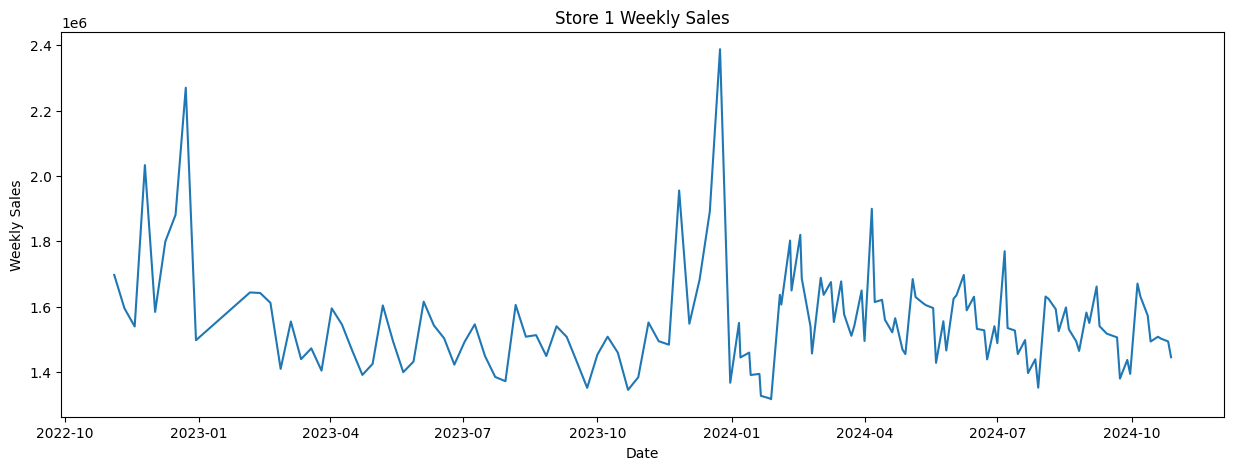

In [15]:
plt.figure(figsize=(15,5))

plt.plot(store1['Weekly_Sales'])

plt.title('Store 1 Weekly Sales')

plt.xlabel('Date')
plt.ylabel('Weekly Sales')

plt.show()

Define Target Variable (Y)

In [17]:
y = store1['Weekly_Sales']

Define Exogenous Variables (X)

In [18]:
X = store1[
[
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment'
]
]

Train-Test Split (80%-20%)

In [19]:
split = int(len(store1)*0.8)

y_train = y[:split]
y_test = y[split:]

X_train = X[:split]
X_test = X[split:]

Check Split Size

In [20]:
print("Train Size :", len(y_train))
print("Test Size :", len(y_test))

Train Size : 114
Test Size : 29


Auto ARIMA

Find best parameters automatically.

In [21]:
auto_model = auto_arima(
    y_train,
    exogenous=X_train,
    seasonal=True,
    m=52,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=3057.846, Time=5.47 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=3070.331, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=3061.854, Time=0.50 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=3064.402, Time=0.34 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=3578.801, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=3055.050, Time=3.37 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(2,0,2)(0,0,2)[52] intercept   : AIC=3057.172, Time=17.09 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=3054.701, Time=4.29 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=3057.905, Time=21.67 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=3060.068, Time=23.87 sec
 ARIMA(1,0,2)(1,0,0)[52] intercept   : AIC=3064.228, Time=1.30 sec
 ARIMA(2,0,1)(1,0,0)[52] intercept   : AIC=3057.562, Time=3.05 sec
 ARIMA(3,0,2)(1,0,0)[52] intercept   : AIC=3058.575, Time=5.32 sec
 ARIMA(2,0,3)(1,0,0)[

Build SARIMAX Model

In [22]:
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(2,0,2),
    seasonal_order=(1,0,0,52)
)

result = model.fit()

print(result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                        Weekly_Sales   No. Observations:                  114
Model:             SARIMAX(2, 0, 2)x(1, 0, [], 52)   Log Likelihood               -1519.440
Date:                             Fri, 19 Jun 2026   AIC                           3060.880
Time:                                     12:06:50   BIC                           3090.978
Sample:                                          0   HQIC                          3073.095
                                             - 114                                         
Covariance Type:                               opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Holiday_Flag  1.047e+05      0.149   7.03e+05      0.000    1.05e+05    1.05e+05
Temperature  -2199.04

| Variable     | Coefficient | P-value | Result        |
| ------------ | ----------: | ------: | ------------- |
| Holiday_Flag |      104700 |   0.000 | Significant ✅ |
| Temperature  |       -2199 |   0.000 | Significant ✅ |
| Fuel_Price   |       28890 |   0.000 | Significant ✅ |
| CPI          |        7521 |   0.000 | Significant ✅ |
| Unemployment |        -927 |   0.000 | Significant ✅ |

========

| Variable     | Coefficient | Impact on Sales | Business Interpretation                                            |
| ------------ | ----------: | --------------- | ------------------------------------------------------------------ |
| Holiday_Flag |     104,700 | Positive ⬆️     | During holiday weeks, Walmart sales increase significantly.        |
| Temperature  |      -2,199 | Negative ⬇️     | As temperature increases, weekly sales tend to decrease slightly.  |
| Fuel_Price   |      28,890 | Positive ⬆️     | Fuel price changes show a positive relationship with weekly sales. |
| CPI          |       7,521 | Positive ⬆️     | Consumer Price Index (CPI) has a strong influence on sales.        |
| Unemployment |        -927 | Negative ⬇️     | Higher unemployment tends to reduce customer spending and sales.   |
==========

| Variable     | P-Value | Significant? |
| ------------ | ------: | ------------ |
| Holiday_Flag |   0.000 | ✅ Yes        |
| Temperature  |   0.000 | ✅ Yes        |
| Fuel_Price   |   0.000 | ✅ Yes        |
| CPI          |   0.000 | ✅ Yes        |
| Unemployment |   0.000 | ✅ Yes        |



Forecast Test Data

In [23]:
forecast = result.predict(
    start=len(y_train),
    end=len(y)-1,
    exog=X_test
)

forecast.index = y_test.index

MAE

In [24]:
mae = mean_absolute_error(
    y_test,
    forecast
)

print("MAE :", round(mae,2))

MAE : 80918.05


RMSE

In [25]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forecast
    )
)

print("RMSE :", round(rmse,2))

RMSE : 95298.96


R² Score

In [26]:
r2 = r2_score(
    y_test,
    forecast
)

print("R2 Score :", round(r2,4))

R2 Score : -0.3086


Actual vs Forecast

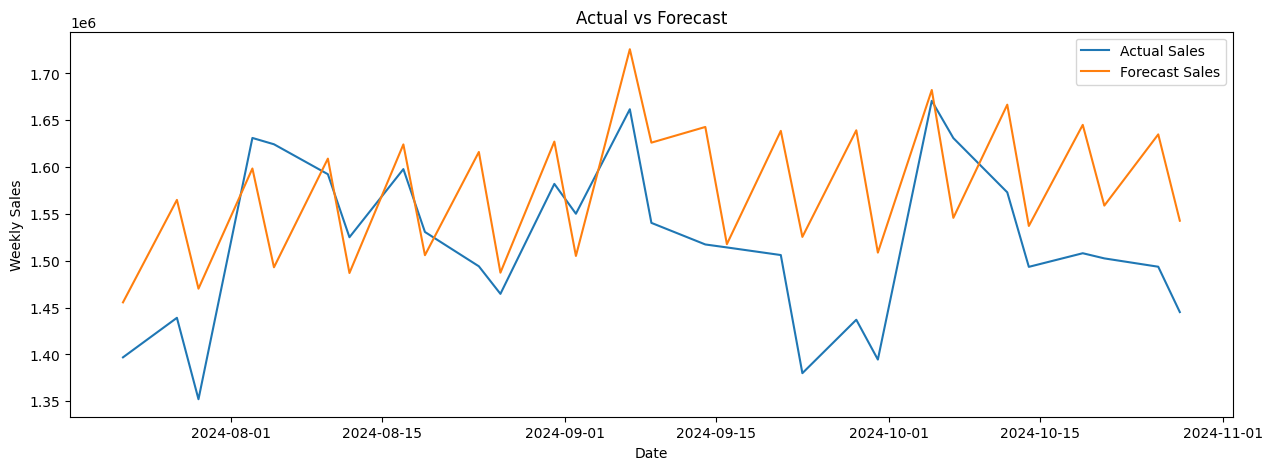

In [27]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test,
    label='Actual Sales'
)

plt.plot(
    forecast,
    label='Forecast Sales'
)

plt.title('Actual vs Forecast')

plt.xlabel('Date')
plt.ylabel('Weekly Sales')

plt.legend()

plt.show()

Create Future Exogenous Variables

Forecast next 12 weeks.

In [29]:
future_exog = pd.DataFrame({
    'Holiday_Flag':[0]*12,
    'Temperature':[X['Temperature'].mean()]*12,
    'Fuel_Price':[X['Fuel_Price'].mean()]*12,
    'CPI':[X['CPI'].mean()]*12,
    'Unemployment':[X['Unemployment'].mean()]*12
})

Forecast Next 12 Weeks

In [30]:
future_forecast = result.forecast(
    steps=12,
    exog=future_exog
)

future_forecast

,predicted_mean
114,1.486223e+06
115,1.545787e+06
116,1.501796e+06
117,1.586535e+06
118,1.534707e+06
119,1.592467e+06
120,1.527499e+06
121,1.604353e+06
122,1.546668e+06
123,1.578060e+06


Display Normal Numbers

In [31]:
future_forecast = future_forecast.round(0)

print(future_forecast)

114    1486223.0
115    1545787.0
116    1501796.0
117    1586535.0
118    1534707.0
119    1592467.0
120    1527499.0
121    1604353.0
122    1546668.0
123    1578060.0
124    1524078.0
125    1593820.0
Name: predicted_mean, dtype: float64


Show Future Dates

weekly sales forecasting:

In [35]:
future_dates = pd.date_range(
    start=store1.index[-1],
    periods=13,
    freq='W'
)[1:]

In [36]:
forecast_df = pd.DataFrame({
    'Forecast_Date': future_dates,
    'Forecast_Sales': future_forecast.astype(int)
})

forecast_df

,Forecast_Date,Forecast_Sales
114,2024-11-10,1486223
115,2024-11-17,1545787
116,2024-11-24,1501796
117,2024-12-01,1586535
118,2024-12-08,1534707
119,2024-12-15,1592467
120,2024-12-22,1527499
121,2024-12-29,1604353
122,2025-01-05,1546668
123,2025-01-12,1578060


In [37]:
forecast_df.reset_index(drop=True, inplace=True)

forecast_df

,Forecast_Date,Forecast_Sales
0,2024-11-10,1486223
1,2024-11-17,1545787
2,2024-11-24,1501796
3,2024-12-01,1586535
4,2024-12-08,1534707
5,2024-12-15,1592467
6,2024-12-22,1527499
7,2024-12-29,1604353
8,2025-01-05,1546668
9,2025-01-12,1578060


Forecast result:



| Metric           | Result              |
| ---------------- | ------------------- |
| Forecast Horizon | 12 Weeks            |
| Lowest Forecast  | 1,486,223           |
| Highest Forecast | 1,604,353           |
| Average Forecast | ~1.55 Million       |
| Forecast Period  | Nov 2024 – Jan 2025 |

========

The SARIMAX model predicts that:

Weekly sales will remain between 1.48 million and 1.60 million.
The highest forecasted sales occur around 29-Dec-2024 with approximately 1.60 million sales.
Sales remain relatively stable with normal fluctuations.
Economic indicators (Fuel Price, CPI, Unemployment, Temperature, Holiday Flag) were used to generate these forecasts.

========


Save Forecast to CSV

In [40]:
forecast_df.to_csv(
    'walmart_forecast.csv'
)

forecast_df.head()

,Forecast_Sales
114,1486223.0
115,1545787.0
116,1501796.0
117,1586535.0
118,1534707.0


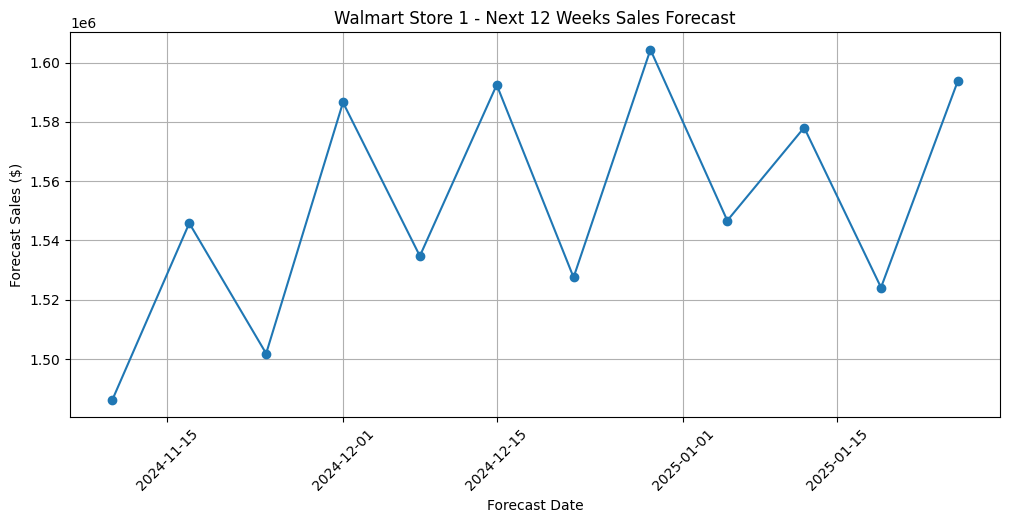

In [47]:
plt.figure(figsize=(12,5))

plt.plot(
    forecast_df['Forecast_Date'],
    forecast_df['Forecast_Sales'],
    marker='o'
)

plt.title('Walmart Store 1 - Next 12 Weeks Sales Forecast')
plt.xlabel('Forecast Date')
plt.ylabel('Forecast Sales ($)')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()